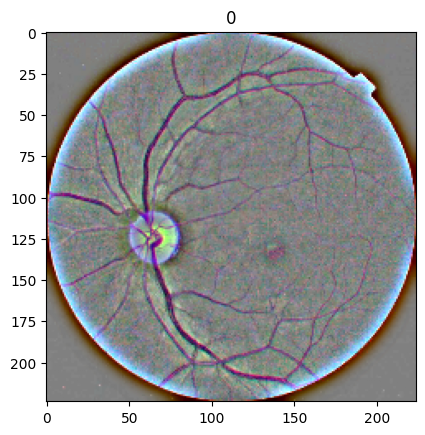

Epoch 1/3
6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 576ms/step - accuracy: 0.4514 - loss: 0.7814 - val_accuracy: 0.6364 - val_loss: 0.6859
Epoch 2/3
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 357ms/step - accuracy: 0.7371 - loss: 0.5734 - val_accuracy: 0.7955 - val_loss: 0.5160
Epoch 3/3
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 361ms/step - accuracy: 0.9029 - loss: 0.4339 - val_accuracy: 0.9091 - val_loss: 0.4097
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 863ms/step
              precision    recall  f1-score   support

           0       0.89      0.89      0.89        19
           1       0.92      0.92      0.92        25

    accuracy                           0.91        44
   macro avg       0.91      0.91      0.91        44
weighted avg       0.91      0.91      0.91        44

[[17  2]
 [ 2 23]]


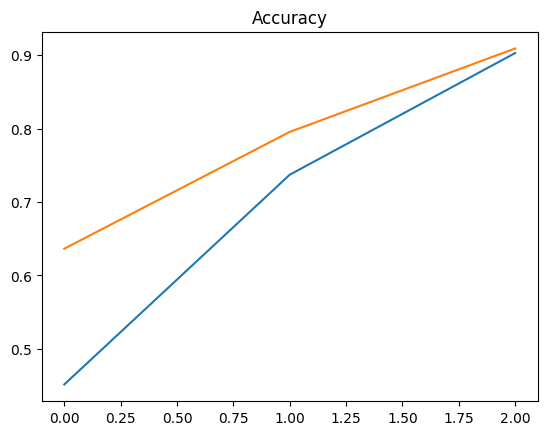

C:\Users\snehi\.conda\envs\retina\lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_632']]
Received: inputs=['Tensor(shape=(1, 224, 224, 3))']
  warnings.warn(msg)


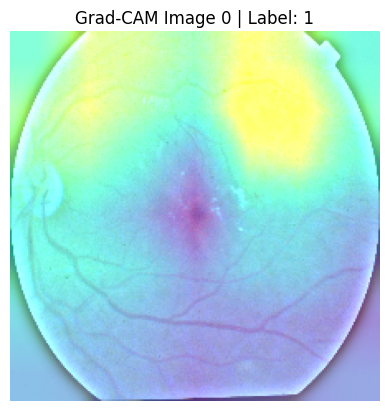

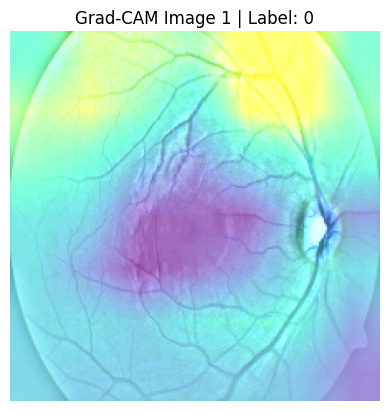

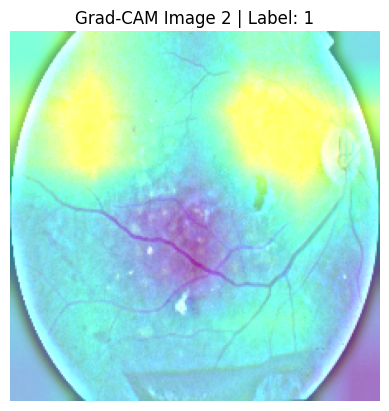

In [5]:
# Import required libraries
import os                      # for folder/file handling
import cv2                     # for image processing
import numpy as np             # for numerical operations
import matplotlib.pyplot as plt  # for plotting images/graphs
from sklearn.model_selection import train_test_split  # to split dataset

# Initialize empty lists to store images and labels
data = []
labels = []

# Path to dataset folder (contains Healthy and Diseased folders)
path = r"C:\Users\snehi\OneDrive\Desktop\dataset"

# Loop through both classes (folders)
for label in ["Healthy", "Diseased"]:
    folder = os.path.join(path, label)   # create full path to each folder
    
    # Assign numerical label: 0 for Healthy, 1 for Diseased
    class_label = 0 if label == "Healthy" else 1

    # Loop through each image in the folder
    for img in os.listdir(folder):
        img_path = os.path.join(folder, img)  # full path to image
        
        image = cv2.imread(img_path)          # read image using OpenCV
        image = cv2.resize(image, (224, 224)) # resize image to 224x224
        image = image / 255.0                 # normalize pixel values (0–1)

        data.append(image)                    # add image to data list
        labels.append(class_label)            # add label to labels list

# Convert lists into numpy arrays for model input
data = np.array(data)
labels = np.array(labels)

# Display one sample image
plt.imshow(data[0])          # show first image
plt.title(labels[0])         # show its label (0 or 1)
plt.show()

# Split dataset into training and testing (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    data, labels, test_size=0.2
)

# Import deep learning model and layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

# Load pre-trained MobileNetV2 model (without top layer)
base_model = MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

# Freeze base model layers (no training on them)
base_model.trainable = False

# Build final model
model = models.Sequential([
    base_model,                        # feature extractor
    layers.GlobalAveragePooling2D(),  # reduce dimensions
    layers.Dense(1, activation='sigmoid')  # binary classification output
])

# Compile model (define optimizer, loss, and metric)
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train model for 3 epochs
history = model.fit(
    X_train, y_train,
    epochs=3,
    validation_data=(X_test, y_test)
)

# Import evaluation metrics
from sklearn.metrics import classification_report, confusion_matrix

# Make predictions on test data
y_pred = model.predict(X_test)

# Convert probabilities to binary labels (0 or 1)
y_pred = (y_pred > 0.5)

# Print classification report (precision, recall, f1-score)
print(classification_report(y_test, y_pred))

# Print confusion matrix
print(confusion_matrix(y_test, y_pred))

# Plot training and validation accuracy
plt.plot(history.history['accuracy'])      # training accuracy
plt.plot(history.history['val_accuracy'])  # validation accuracy
plt.title("Accuracy")
plt.show()

# Import Grad-CAM for explainability
from tf_explain.core.grad_cam import GradCAM

# Initialize Grad-CAM
explainer = GradCAM()

# Extract CNN part (MobileNetV2)
conv_model = model.layers[0]

# Generate Grad-CAM for 3 different test images
for i in range(3):
    
    img = X_test[i]                          # select image
    img_input = np.expand_dims(img, axis=0)  # reshape to (1,224,224,3)

    # Use actual label of that image (important for correct heatmap)
    class_idx = int(y_test[i])

    # Generate Grad-CAM heatmap
    grid = explainer.explain( 
        validation_data=(img_input, None),
        model=conv_model,
        class_index=class_idx,
        layer_name="Conv_1"
    )

    # Display Grad-CAM result
    plt.imshow(grid)
    plt.title(f"Grad-CAM Image {i} | Label: {y_test[i]}")
    plt.axis('off')
    
    # Save Grad-CAM image
    plt.savefig(f"gradcam_{i}.png")
    
    plt.show()
    


## Conclusion

A MobileNetV2-based transfer learning model was developed to classify retina images into Healthy and Diseased categories. The dataset was preprocessed by resizing images to 224×224 and normalizing pixel values, followed by an 80–20 train-test split. The model was trained for 3 epochs and achieved approximately 90–91% validation accuracy. Evaluation metrics including precision, recall, and confusion matrix indicate strong and balanced performance across both classes. Grad-CAM visualizations highlight key retinal regions such as blood vessels and affected areas, showing that the model focuses on meaningful features for prediction. The results demonstrate effective learning, and performance can be further improved with a larger dataset and fine-tuning.